### 전처리 최종본

# 1. 라이브러리 Import

In [1]:
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from scipy.stats import skew, kurtosis
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg
import scikit_posthocs as sp
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)

print("=" * 60)
print("라이브러리 로드 완료!")
print("=" * 60)

라이브러리 로드 완료!


# 2. 데이터 로드

In [2]:
base_path = "data"
meta_path = os.path.join(base_path, "metadata.csv")
df = pd.read_csv(meta_path)
print(df.shape)
df.head()

(7565, 10)


,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN


# 3. start_time 전처리

In [3]:
def clear_time(x):
    if pd.isna(x): return pd.NaT
    x = str(x)
    nums = []
    current = ''
    for ch in x:
        if ch.isdigit() or ch in ['.', 'e', 'E', '+', '-']:
            current += ch
        else:
            if current != '':
                nums.append(current)
                current = ''
    if current != '': nums.append(current)
    if len(nums) < 6: return pd.NaT
    try: nums = list(map(float, nums[:6]))
    except: return pd.NaT
    year, month, day, hour, minute, second = nums
    if not (2000 <= year <= 2100 and 1 <= month <= 12 and
            1 <= day <= 31 and 0 <= hour < 24 and
            0 <= minute < 60 and 0 <= second < 60): return pd.NaT
    try: return pd.Timestamp(int(year), int(month), int(day), int(hour), int(minute), int(second))
    except: return pd.NaT

df['start_time'] = df['start_time'].apply(clear_time)
df = df.dropna(subset=['start_time'])

### 3-1. 시간 파생 컬럼

- `elapsed_hours_from_first`: 첫 가동 후 경과 시간
- `hours_from_prev_operation`: 직전 작업 시작시각과의 차이 (charge·discharge·impedance 포함, 휴지기+작업시간 혼재)

In [4]:
df = df.sort_values(by=['battery_id', 'start_time']).reset_index(drop=True)

df['elapsed_hours_from_first'] = df.groupby('battery_id')['start_time'].transform(
    lambda x: (x - x.min()).dt.total_seconds() / 3600
)

# 변수명 변경
# 주의: 직전 discharge 이후 순수 휴지시간이 아니라
#       charge·discharge·impedance 포함한 직전 작업 시작시각과의 차이
df['hours_from_prev_operation'] = (
    df.groupby('battery_id')['start_time'].diff().dt.total_seconds() / 3600
)
df['hours_from_prev_operation'] = df['hours_from_prev_operation'].fillna(0)

# 4. 그룹 컬럼 추가

In [5]:
group_map = {
    'B0005':'A','B0006':'A','B0007':'A','B0018':'A',
    'B0025':'B','B0026':'B','B0027':'B','B0028':'B',
    'B0029':'C','B0030':'C','B0031':'C','B0032':'C',
    'B0033':'D','B0034':'D','B0036':'D',
    'B0038':'E','B0039':'E','B0040':'E',
    'B0041':'F','B0042':'F','B0043':'F','B0044':'F',
    'B0045':'G','B0046':'G','B0047':'G','B0048':'G',
    'B0049':'H','B0050':'H','B0051':'H','B0052':'H',
    'B0053':'I','B0054':'I','B0055':'I','B0056':'I',
}

end_reason_map = {
    'A': 'EOL',      'B': 'censored', 'C': 'censored',
    'D': 'QA_issue', 'E': 'QA_issue', 'F': 'QA_issue',
    'G': 'QA_issue', 'H': 'crashed',  'I': 'QA_issue',
}

analysis_role_map = {
    'A': 'main',    'B': 'excluded',  'C': 'comparison',
    'D': 'excluded','E': 'excluded',  'F': 'anomaly',
    'G': 'anomaly', 'H': 'anomaly',   'I': 'anomaly',
}

df['group']         = df['battery_id'].map(group_map)
df['end_reason']    = df['group'].map(end_reason_map)
df['analysis_role'] = df['group'].map(analysis_role_map)

print("\n그룹별 배터리 수 및 역할:")
summary = df.groupby(['group','end_reason','analysis_role'])['battery_id'].nunique().reset_index()
summary.columns = ['group','end_reason','analysis_role','배터리수']
print(summary.to_string(index=False))


그룹별 배터리 수 및 역할:
group end_reason analysis_role  배터리수
    A        EOL          main     4
    B   censored      excluded     4
    C   censored    comparison     4
    D   QA_issue      excluded     3
    E   QA_issue      excluded     3
    F   QA_issue       anomaly     4
    G   QA_issue       anomaly     4
    H    crashed       anomaly     4
    I   QA_issue       anomaly     4


# 5. 실험 조건 라벨

-  `test_temperature_profile`: 원본 `ambient_temperature`와 분리
-  F그룹 `4°C_22°C_mixed`

In [6]:
test_temperature_profile_map = {
    'A': '24°C_stable',    'B': '24°C_stable',
    'C': '43°C_stable',    'D': '24°C_stable',
    'E': '24_44°C_mixed',
    'F': '4°C_22°C_mixed',  # 실제 데이터에 4°C와 22°C 혼재
    'G': '4°C_stable',    'H': '4°C_stable',    'I': '4°C_stable',
}

load_profile_map = {
    'A': '2A_CC',         'B': '4A_squarewave', 'C': '4A_CC',
    'D': '2A_4A_mixed',   'E': '1A_2A_4A_mixed','F': '4A_1A_mixed',
    'G': '1A_CC',         'H': '2A_CC',         'I': '2A_CC',
}

eol_rule_source_map = {
    'A': 'NASA_30%fade', 'B': 'censored',      'C': 'censored',
    'D': 'NASA_20%fade', 'E': 'NASA_20%fade',
    'F': 'NASA_30%fade', 'G': 'NASA_30%fade',
    'H': 'crashed',      'I': 'NASA_30%fade',
}

df['test_temperature_profile'] = df['group'].map(test_temperature_profile_map)
df['load_profile']             = df['group'].map(load_profile_map)
df['eol_rule_source']          = df['group'].map(eol_rule_source_map)

In [7]:
# battery_protocol_map — README 기반 정확한 값
# 출처: NASA README 각 그룹별 파일
# 각 배터리의 discharge cutoff voltage가 개별적으로 다름

battery_protocol_map = {
    # -------------------------------------------------------
    # 그룹A (README_05_06_07_18)
    # 2A CC, 24°C, EOL 30% fade (2Ah → 1.4Ah)
    # cutoff: 2.7V/2.5V/2.2V/2.5V for B5/B6/B7/B18
    # -------------------------------------------------------
    'B0005': {'cutoff_voltage': 2.7, 'discharge_current': '2A_CC',          'eol_fade': 0.30},
    'B0006': {'cutoff_voltage': 2.5, 'discharge_current': '2A_CC',          'eol_fade': 0.30},
    'B0007': {'cutoff_voltage': 2.2, 'discharge_current': '2A_CC',          'eol_fade': 0.30},
    'B0018': {'cutoff_voltage': 2.5, 'discharge_current': '2A_CC',          'eol_fade': 0.30},

    # -------------------------------------------------------
    # 그룹B (README_25_26_27_28)
    # 4A squarewave 0.05Hz 50% duty, 24°C
    # cutoff: 2.0V/2.2V/2.5V/2.7V for B25/B26/B27/B28
    # -------------------------------------------------------
    'B0025': {'cutoff_voltage': 2.0, 'discharge_current': '4A_squarewave',  'eol_fade': None},
    'B0026': {'cutoff_voltage': 2.2, 'discharge_current': '4A_squarewave',  'eol_fade': None},
    'B0027': {'cutoff_voltage': 2.5, 'discharge_current': '4A_squarewave',  'eol_fade': None},
    'B0028': {'cutoff_voltage': 2.7, 'discharge_current': '4A_squarewave',  'eol_fade': None},

    # -------------------------------------------------------
    # 그룹C (README_29_30_31_32)
    # 4A CC, 43°C
    # cutoff: 2.0V/2.2V/2.5V/2.7V for B29/B30/B31/B32
    # -------------------------------------------------------
    'B0029': {'cutoff_voltage': 2.0, 'discharge_current': '4A_CC',          'eol_fade': None},
    'B0030': {'cutoff_voltage': 2.2, 'discharge_current': '4A_CC',          'eol_fade': None},
    'B0031': {'cutoff_voltage': 2.5, 'discharge_current': '4A_CC',          'eol_fade': None},
    'B0032': {'cutoff_voltage': 2.7, 'discharge_current': '4A_CC',          'eol_fade': None},

    # -------------------------------------------------------
    # 그룹D (README_33_34_36)
    # B0033: 4A CC, till 2.0V
    # B0034: 4A CC, till 2.2V
    # B0036: 2A CC, till 2.7V
    # EOL 20% fade (2Ah → 1.6Ah)
    # -------------------------------------------------------
    'B0033': {'cutoff_voltage': 2.0, 'discharge_current': '4A_CC',          'eol_fade': 0.20},
    'B0034': {'cutoff_voltage': 2.2, 'discharge_current': '4A_CC',          'eol_fade': 0.20},
    'B0036': {'cutoff_voltage': 2.7, 'discharge_current': '2A_CC',          'eol_fade': 0.20},

    # -------------------------------------------------------
    # 그룹E (README_38_39_40)
    # 1A/2A/4A mixed, 24&44°C
    # B0038: till 2.2V, B0039: till 2.5V, B0040: till 2.7V
    # EOL 20% fade
    # -------------------------------------------------------
    'B0038': {'cutoff_voltage': 2.2, 'discharge_current': '1A_2A_4A_mixed', 'eol_fade': 0.20},
    'B0039': {'cutoff_voltage': 2.5, 'discharge_current': '1A_2A_4A_mixed', 'eol_fade': 0.20},
    'B0040': {'cutoff_voltage': 2.7, 'discharge_current': '1A_2A_4A_mixed', 'eol_fade': 0.20},

    # -------------------------------------------------------
    # 그룹F (README_41_42_43_44)
    # 4A and 1A mixed, 4°C
    # B0041: till 2.0V, B0042: till 2.2V, B0043: till 2.5V, B0044: till 2.7V
    # EOL 30% fade (2Ah → 1.4Ah)
    # -------------------------------------------------------
    'B0041': {'cutoff_voltage': 2.0, 'discharge_current': '4A_1A_mixed',    'eol_fade': 0.30},
    'B0042': {'cutoff_voltage': 2.2, 'discharge_current': '4A_1A_mixed',    'eol_fade': 0.30},
    'B0043': {'cutoff_voltage': 2.5, 'discharge_current': '4A_1A_mixed',    'eol_fade': 0.30},
    'B0044': {'cutoff_voltage': 2.7, 'discharge_current': '4A_1A_mixed',    'eol_fade': 0.30},

    # -------------------------------------------------------
    # 그룹G (README_45_46_47_48)
    # 1A CC, 4°C
    # B0045: till 2.0V, B0046: till 2.2V, B0047: till 2.5V, B0048: till 2.7V
    # EOL 30% fade
    # -------------------------------------------------------
    'B0045': {'cutoff_voltage': 2.0, 'discharge_current': '1A_CC',          'eol_fade': 0.30},
    'B0046': {'cutoff_voltage': 2.2, 'discharge_current': '1A_CC',          'eol_fade': 0.30},
    'B0047': {'cutoff_voltage': 2.5, 'discharge_current': '1A_CC',          'eol_fade': 0.30},
    'B0048': {'cutoff_voltage': 2.7, 'discharge_current': '1A_CC',          'eol_fade': 0.30},

    # -------------------------------------------------------
    # 그룹H (README_49_50_51_52)
    # 2A CC, 4°C, SW 크래시로 종료 → EOL 기준 없음
    # B0049: till 2.0V, B0050: till 2.2V, B0051: till 2.5V, B0052: till 2.7V
    # -------------------------------------------------------
    'B0049': {'cutoff_voltage': 2.0, 'discharge_current': '2A_CC',          'eol_fade': None},
    'B0050': {'cutoff_voltage': 2.2, 'discharge_current': '2A_CC',          'eol_fade': None},
    'B0051': {'cutoff_voltage': 2.5, 'discharge_current': '2A_CC',          'eol_fade': None},
    'B0052': {'cutoff_voltage': 2.7, 'discharge_current': '2A_CC',          'eol_fade': None},

    # -------------------------------------------------------
    # 그룹I (README_53_54_55_56)
    # 2A CC, 4°C
    # B0053: till 2.0V, B0054: till 2.2V, B0055: till 2.5V, B0056: till 2.7V
    # EOL 30% fade
    # -------------------------------------------------------
    'B0053': {'cutoff_voltage': 2.0, 'discharge_current': '2A_CC',          'eol_fade': 0.30},
    'B0054': {'cutoff_voltage': 2.2, 'discharge_current': '2A_CC',          'eol_fade': 0.30},
    'B0055': {'cutoff_voltage': 2.5, 'discharge_current': '2A_CC',          'eol_fade': 0.30},
    'B0056': {'cutoff_voltage': 2.7, 'discharge_current': '2A_CC',          'eol_fade': 0.30},
}

df['cutoff_voltage']     = df['battery_id'].map({k: v['cutoff_voltage']    for k, v in battery_protocol_map.items()})
df['discharge_current']  = df['battery_id'].map({k: v['discharge_current'] for k, v in battery_protocol_map.items()})
df['eol_fade_threshold'] = df['battery_id'].map({k: v['eol_fade']          for k, v in battery_protocol_map.items()})

print("=" * 60)
print("battery_protocol_map 적용 완료 (README 기준)")
print("=" * 60)
print(df.groupby('battery_id')[['group','cutoff_voltage','discharge_current','eol_fade_threshold']].first().to_string())

battery_protocol_map 적용 완료 (README 기준)
           group  cutoff_voltage discharge_current  eol_fade_threshold
battery_id                                                            
B0005          A             2.7             2A_CC                 0.3
B0006          A             2.5             2A_CC                 0.3
B0007          A             2.2             2A_CC                 0.3
B0018          A             2.5             2A_CC                 0.3
B0025          B             2.0     4A_squarewave                 NaN
B0026          B             2.2     4A_squarewave                 NaN
B0027          B             2.5     4A_squarewave                 NaN
B0028          B             2.7     4A_squarewave                 NaN
B0029          C             2.0             4A_CC                 NaN
B0030          C             2.2             4A_CC                 NaN
B0031          C             2.5             4A_CC                 NaN
B0032          C             2.7      

# 6. 타입별 3개 테이블 분리

In [8]:
df_charge    = df[df['type'] == 'charge'].copy()
df_discharge = df[df['type'] == 'discharge'].copy()
df_impedance = df[df['type'] == 'impedance'].copy()

print(f"df_charge    : {len(df_charge):,}행")
print(f"df_discharge : {len(df_discharge):,}행")
print(f"df_impedance : {len(df_impedance):,}행")

df_charge    : 2,815행
df_discharge : 2,794행
df_impedance : 1,956행


# 7. Capacity 상태 flag

In [9]:
df_discharge['Capacity'] = pd.to_numeric(df_discharge['Capacity'], errors='coerce')

def classify_capacity(cap):
    if pd.isna(cap):   return 'missing'
    elif cap == 0:     return 'zero'
    elif cap > 2.1:    return 'impossible_high'
    elif cap < 0.3:    return 'low_anomaly'
    else:              return 'valid'

df_discharge['cap_flag']    = df_discharge['Capacity'].apply(classify_capacity)
hard_exclude = ['missing', 'zero', 'impossible_high']
df_discharge['cap_exclude'] = df_discharge['cap_flag'].isin(hard_exclude)
df_discharge['cap_anomaly'] = df_discharge['cap_flag'] == 'low_anomaly'

print(df_discharge['cap_flag'].value_counts())
print(f"\n하드 제외: {df_discharge['cap_exclude'].sum()}건")
print(f"이상탐지: {df_discharge['cap_anomaly'].sum()}건")

cap_flag
valid              2553
low_anomaly         193
missing              25
zero                 19
impossible_high       4
Name: count, dtype: int64

하드 제외: 48건
이상탐지: 193건


### 7-1. Impedance 상태 flag

In [10]:
df_impedance['Re']  = pd.to_numeric(df_impedance['Re'],  errors='coerce')
df_impedance['Rct'] = pd.to_numeric(df_impedance['Rct'], errors='coerce')
df_impedance = df_impedance.sort_values(['battery_id','start_time']).reset_index(drop=True)
df_impedance['re_diff'] = df_impedance.groupby('battery_id')['Re'].diff().abs()

def classify_impedance(row):
    re, rct, diff = row['Re'], row['Rct'], row['re_diff']
    if pd.isna(re) or pd.isna(rct):   return 'missing'
    if re <= 0 or rct <= 0:           return 'zero_or_minus'
    if pd.notna(diff) and diff > 0.3: return 'noise_candidate'
    if rct > re * 10:                 return 'rct_imbalance'
    if re > 1.0 or rct > 1.5:        return 'high_anomaly'
    return 'valid'

df_impedance['imp_flag']    = df_impedance.apply(classify_impedance, axis=1)
df_impedance['imp_exclude'] = df_impedance['imp_flag'].isin(['missing','zero_or_minus'])
df_impedance['imp_anomaly'] = df_impedance['imp_flag'].isin(['high_anomaly','noise_candidate','rct_imbalance'])

print(df_impedance['imp_flag'].value_counts())
print(f"\n하드 제외: {df_impedance['imp_exclude'].sum()}건")
print(f"이상탐지: {df_impedance['imp_anomaly'].sum()}건")

imp_flag
valid              1932
zero_or_minus        11
missing               9
noise_candidate       4
Name: count, dtype: int64

하드 제외: 20건
이상탐지: 4건


# 8. discharge 사이클 순번

In [11]:
df_discharge = df_discharge.sort_values(
    ['battery_id','start_time','filename']
).reset_index(drop=True)

df_discharge['discharge_cycle_raw'] = (
    df_discharge.groupby('battery_id').cumcount() + 1
)
df_discharge['is_hard_excluded'] = df_discharge['cap_flag'].isin(
    ['missing','zero','impossible_high']
)
df_discharge['discharge_cycle_valid'] = (
    df_discharge.loc[~df_discharge['is_hard_excluded']]
    .groupby('battery_id').cumcount() + 1
)

# 9. 초기 Capacity 계산

In [12]:
init_cap = (
    df_discharge[df_discharge['cap_flag'] == 'valid']
    .groupby('battery_id')['Capacity']
    .apply(lambda x: x.head(5).median())
    .rename('init_cap')
)
df_discharge = df_discharge.merge(init_cap, on='battery_id', how='left')

print("초기 Capacity (valid 첫 5개 중앙값):")
print(df_discharge.groupby(['battery_id','group'])['init_cap'].first().reset_index().round(4).to_string(index=False))

초기 Capacity (valid 첫 5개 중앙값):
battery_id group  init_cap
     B0005     A    1.8353
     B0006     A    2.0133
     B0007     A    1.8807
     B0018     A    1.8396
     B0025     B    1.8471
     B0026     B    1.8143
     B0027     B    1.8142
     B0028     B    1.7976
     B0029     C    1.8158
     B0030     C    1.7518
     B0031     C    1.8044
     B0032     C    1.8655
     B0033     D    1.2529
     B0034     D    1.6207
     B0036     D    1.8011
     B0038     E    1.0613
     B0039     E    0.4711
     B0040     E    0.7796
     B0041     F    1.1195
     B0042     F    1.7282
     B0043     F    1.6815
     B0044     F    1.6534
     B0045     G    0.8852
     B0046     G    1.5031
     B0047     G    1.5081
     B0048     G    1.4989
     B0049     H    1.3644
     B0050     H    1.5518
     B0051     H    1.2039
     B0052     H    1.3611
     B0053     I    1.1306
     B0054     I    1.0960
     B0055     I    1.2573
     B0056     I    1.2974


# 10. SOH 계산

In [13]:
df_discharge['SOH_nominal'] = np.where(
    df_discharge['cap_flag'] == 'valid',
    (df_discharge['Capacity'] / 2.0 * 100).round(2), np.nan
)

# SOH_relative가 초반에 100% 초과하는 경우 있음
# 이유: init_cap = valid 첫 5개 중앙값 기준이라
#       초반 측정값이 중앙값보다 살짝 높으면 100% 초과 가능
# → 계산 오류 아님. 정상적인 구조적 특성.
df_discharge['SOH_relative'] = np.where(
    df_discharge['cap_flag'] == 'valid',
    (df_discharge['Capacity'] / df_discharge['init_cap'] * 100).round(2), np.nan
)

# 11. EOL & RUL 계산

`rul_label_type` — main만 supervised

In [14]:
for col in ['eol_cycle','RUL','eol_soh_threshold']:
    if col in df_discharge.columns:
        df_discharge = df_discharge.drop(columns=col)

eol_threshold_map = {
    'A': 70, 'B': 70, 'C': 70,
    'D': 80, 'E': 80,
    'F': 70, 'G': 70, 'H': None, 'I': 70
}
df_discharge['eol_soh_threshold'] = df_discharge['group'].map(eol_threshold_map)

eol_cycles = (
    df_discharge[
        (df_discharge['cap_flag'] == 'valid') &
        (df_discharge['eol_soh_threshold'].notna()) &
        (df_discharge['SOH_nominal'] < df_discharge['eol_soh_threshold'])
    ]
    .groupby('battery_id')['discharge_cycle_raw'].min()
    .rename('eol_cycle').reset_index()
)
df_discharge = df_discharge.merge(eol_cycles, on='battery_id', how='left')

df_discharge['RUL'] = np.where(
    df_discharge['eol_cycle'].notna(),
    (df_discharge['eol_cycle'] - df_discharge['discharge_cycle_raw']).clip(lower=0),
    np.nan
)

# rul_label_type
df_discharge['rul_label_type'] = np.where(
    df_discharge['analysis_role'] == 'main',       'supervised',
np.where(
    df_discharge['analysis_role'] == 'comparison', 'censored',
np.where(
    df_discharge['analysis_role'] == 'anomaly',    'anomaly_case',
    'unsupported_for_rul'
)))

print("rul_label_type 분포:")
print(df_discharge['rul_label_type'].value_counts())

eol_summary = (
    df_discharge.groupby('battery_id')
    .agg(
        group=('group','first'), rul_label_type=('rul_label_type','first'),
        eol_cycle=('eol_cycle','first'), total_cycles=('discharge_cycle_raw','max'),
        rul_available=('RUL', lambda x: x.notna().sum()),
    ).reset_index()
)
eol_summary['eol_달성'] = eol_summary['eol_cycle'].notna().map({True:'O',False:'X'})
print("\n" + "="*55)
print(eol_summary.to_string(index=False))

rul_label_type 분포:
rul_label_type
anomaly_case           1154
unsupported_for_rul     844
supervised              636
censored                160
Name: count, dtype: int64

battery_id group      rul_label_type  eol_cycle  total_cycles  rul_available eol_달성
     B0005     A          supervised      125.0           168            168      O
     B0006     A          supervised      109.0           168            168      O
     B0007     A          supervised        NaN           168              0      X
     B0018     A          supervised       97.0           132            132      O
     B0025     B unsupported_for_rul        NaN            28              0      X
     B0026     B unsupported_for_rul        6.0            28             28      O
     B0027     B unsupported_for_rul        NaN            28              0      X
     B0028     B unsupported_for_rul        NaN            28              0      X
     B0029     C            censored        NaN            40          

# 12. 그룹별 DataFrame 분리

In [15]:
df_main       = df_discharge[df_discharge['analysis_role'] == 'main'].copy()
df_comparison = df_discharge[df_discharge['analysis_role'] == 'comparison'].copy()
df_anomaly    = df_discharge[df_discharge['analysis_role'] == 'anomaly'].copy()
df_excluded   = df_discharge[df_discharge['analysis_role'] == 'excluded'].copy()

# 13. impedance 전처리 및 역할별 분리

In [16]:
df_impedance['group']         = df_impedance['battery_id'].map(group_map)
df_impedance['end_reason']    = df_impedance['group'].map(end_reason_map)
df_impedance['analysis_role'] = df_impedance['group'].map(analysis_role_map)
df_impedance = df_impedance.sort_values(['battery_id','test_id'])
df_impedance['impedance_cycle_no'] = df_impedance.groupby('battery_id').cumcount() + 1

df_imp_main       = df_impedance[df_impedance['analysis_role'] == 'main'].copy()
df_imp_comparison = df_impedance[df_impedance['analysis_role'] == 'comparison'].copy()
df_imp_anomaly    = df_impedance[df_impedance['analysis_role'] == 'anomaly'].copy()

group_dfs = {grp: df_discharge[df_discharge['group']==grp].copy()
             for grp in sorted(df_discharge['group'].unique())}

print(f"df_imp_main       : {len(df_imp_main):>4}행")
print(f"df_imp_comparison : {len(df_imp_comparison):>4}행")
print(f"df_imp_anomaly    : {len(df_imp_anomaly):>4}행")
print(f"\ndf_main       : {len(df_main):>4}행  {df_main['battery_id'].nunique()}개 배터리")
print(f"df_comparison : {len(df_comparison):>4}행  {df_comparison['battery_id'].nunique()}개 배터리")
print(f"df_anomaly    : {len(df_anomaly):>4}행  {df_anomaly['battery_id'].nunique()}개 배터리")

df_imp_main       :  887행
df_imp_comparison :   68행
df_imp_anomaly    :  557행

df_main       :  636행  4개 배터리
df_comparison :  160행  4개 배터리
df_anomaly    : 1154행  16개 배터리


# 14. ML용 데이터셋 생성

** 핵심 수정**

- `merge_asof` backward join: start_time 기준 과거값만 사용
- `impedance_available` 플래그: 첫 impedance 이전/이후 구간 구분
-  조건부 ffill: 이전 구간 NaN 유지, 이후 구간만 ffill
- `battery_id` feature 제외 (GroupKFold용으로만 유지)

In [17]:
# ============================================================
# merge_asof backward join
# 기존 문제: cycle 번호 근사 매핑 → 배터리별 impedance 수가 달라서 불일치
#   B0005~7: discharge 168개, impedance 278개
#   B0018: discharge 132개, impedance 53개
# 수정: start_time 기준 backward asof join
#   → 현재 discharge 시점보다 이전의 가장 최근 impedance 누적 평균 사용
#   → 미래 impedance 정보 누수 완전 차단
# ============================================================

imp_A = df_imp_main[['battery_id','start_time','Re','Rct']].copy()
imp_A['Re']  = pd.to_numeric(imp_A['Re'],  errors='coerce')
imp_A['Rct'] = pd.to_numeric(imp_A['Rct'], errors='coerce')
imp_A = imp_A.sort_values(['battery_id','start_time']).reset_index(drop=True)

# cumulative mean (현재까지 관측된 누적 평균)
imp_A['Re_cumean']  = (
    imp_A.groupby('battery_id')['Re']
    .expanding().mean().reset_index(level=0, drop=True)
)
imp_A['Rct_cumean'] = (
    imp_A.groupby('battery_id')['Rct']
    .expanding().mean().reset_index(level=0, drop=True)
)

# discharge 데이터 준비
dis_A = (
    df_main[df_main['cap_flag'] == 'valid']
    [['battery_id','start_time','discharge_cycle_raw',
      'discharge_cycle_valid','SOH_relative','SOH_nominal',
      'ambient_temperature','RUL','rul_label_type']]
    .dropna(subset=['RUL'])
    .query("rul_label_type == 'supervised'")
    .sort_values(['battery_id','start_time'])
    .reset_index(drop=True)
    .copy()
)

# 배터리별 merge_asof backward join
results = []
for bid in dis_A['battery_id'].unique():
    d = dis_A[dis_A['battery_id']==bid].sort_values('start_time').reset_index(drop=True)
    i = imp_A[imp_A['battery_id']==bid][['start_time','Re_cumean','Rct_cumean']].sort_values('start_time').reset_index(drop=True)
    merged = pd.merge_asof(d, i, on='start_time', direction='backward')
    results.append(merged)

df_ml = pd.concat(results, ignore_index=True)
df_ml = df_ml.rename(columns={'Re_cumean':'Re_mean','Rct_cumean':'Rct_mean'})

# impedance_available 플래그
# 첫 impedance 측정 이전 구간: 과거 정보 없음 → 정상 결측
# 첫 impedance 측정 이후 구간: ffill 적용 가능
first_imp = imp_A.groupby('battery_id')['start_time'].min().rename('first_imp_time')
df_ml = df_ml.merge(first_imp, on='battery_id', how='left')
df_ml['impedance_available'] = df_ml['start_time'] >= df_ml['first_imp_time']

# 조건부 ffill
# 이후 구간: 마지막 cumulative mean 유지
# 이전 구간: NaN 유지 (과거 정보 없음, 강제 fill 금지)
df_ml = df_ml.sort_values(['battery_id','discharge_cycle_raw'])
df_ml['Re_mean']  = df_ml.groupby('battery_id')['Re_mean'].ffill()
df_ml['Rct_mean'] = df_ml.groupby('battery_id')['Rct_mean'].ffill()

print("=" * 55)
print("ML용 데이터셋 (merge_asof 적용)")
print("=" * 55)
print(f"총 행 수                : {len(df_ml)}")
print(f"배터리 수               : {df_ml['battery_id'].nunique()}")
print(f"impedance 이전(정상 NaN): {(~df_ml['impedance_available']).sum()}행")
print(f"impedance 이후         : {df_ml['impedance_available'].sum()}행")
print(f"Re_mean NaN            : {df_ml['Re_mean'].isna().sum()}")
print(f"Rct_mean NaN           : {df_ml['Rct_mean'].isna().sum()}")
print(f"\n결측치 전체:")
print(df_ml[[c for c in df_ml.columns if c != 'first_imp_time']].isnull().sum())
print(f"\n샘플 (앞 10행):")
print(df_ml[['battery_id','discharge_cycle_raw','SOH_relative','Re_mean','Rct_mean','RUL','impedance_available']].head(10).to_string(index=False))

ML용 데이터셋 (merge_asof 적용)
총 행 수                : 468
배터리 수               : 3
impedance 이전(정상 NaN): 38행
impedance 이후         : 430행
Re_mean NaN            : 38
Rct_mean NaN           : 38

결측치 전체:
battery_id                0
start_time                0
discharge_cycle_raw       0
discharge_cycle_valid     0
SOH_relative              0
SOH_nominal               0
ambient_temperature       0
RUL                       0
rul_label_type            0
Re_mean                  38
Rct_mean                 38
impedance_available       0
dtype: int64

샘플 (앞 10행):
battery_id  discharge_cycle_raw  SOH_relative  Re_mean  Rct_mean   RUL  impedance_available
     B0005                    1        101.15      NaN       NaN 124.0                False
     B0005                    2        100.60      NaN       NaN 123.0                False
     B0005                    3        100.00      NaN       NaN 122.0                False
     B0005                    4        100.00      NaN       NaN 121.0     

# 15. 전체 저장

In [18]:
os.makedirs(base_path, exist_ok=True)

df_discharge.to_csv(os.path.join(base_path, 'df_discharge_processed.csv'), index=False)
df_main.to_csv(os.path.join(base_path, 'df_A_main.csv'), index=False)
df_comparison.to_csv(os.path.join(base_path, 'df_C_comparison.csv'), index=False)
df_anomaly.to_csv(os.path.join(base_path, 'df_anomaly.csv'), index=False)

for grp, gdf in group_dfs.items():
    gdf.to_csv(os.path.join(base_path, f'df_group_{grp}.csv'), index=False)

df_impedance.to_csv(os.path.join(base_path, 'df_impedance_processed.csv'), index=False)
df_imp_main.to_csv(os.path.join(base_path, 'df_imp_A_main.csv'), index=False)
df_imp_comparison.to_csv(os.path.join(base_path, 'df_imp_C_comparison.csv'), index=False)

# battery_id는 GroupKFold용으로 유지하되 저장
df_ml.to_csv(os.path.join(base_path, 'df_ml_dataset.csv'), index=False)

print("\n" + "=" * 55)
print("전체 저장 완료")
print("=" * 55)
print("df_discharge_processed.csv  — 전체 34개 배터리 discharge")
print("df_A_main.csv               — 그룹A 메인 분석")
print("df_C_comparison.csv         — 그룹C 온도 비교")
print("df_anomaly.csv              — 그룹F·G·H·I 이상탐지")
print("df_group_{A~I}.csv          — 그룹별 개별 파일")
print("df_impedance_processed.csv  — 전체 impedance")
print("df_imp_A_main.csv           — 그룹A impedance")
print("df_imp_C_comparison.csv     — 그룹C impedance")
print("df_ml_dataset.csv           — ML 학습용 데이터셋")
print("\n다음 단계: 02_EDA.ipynb")


전체 저장 완료
df_discharge_processed.csv  — 전체 34개 배터리 discharge
df_A_main.csv               — 그룹A 메인 분석
df_C_comparison.csv         — 그룹C 온도 비교
df_anomaly.csv              — 그룹F·G·H·I 이상탐지
df_group_{A~I}.csv          — 그룹별 개별 파일
df_impedance_processed.csv  — 전체 impedance
df_imp_A_main.csv           — 그룹A impedance
df_imp_C_comparison.csv     — 그룹C impedance
df_ml_dataset.csv           — ML 학습용 데이터셋

다음 단계: 02_EDA.ipynb


# 16. 머신러닝 파트 정리본

1. 전처리 최종본에서 이미 만든 df_ml을 다시 활용
2. SOH / RUL / raw feature 추가 전후 흐름을 분리해서 본다.

In [19]:
import warnings

from sklearn.model_selection import GroupShuffleSplit, LeaveOneGroupOut
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')

try:
    import shap
    SHAP_AVAILABLE = True
except Exception as e:
    shap = None
    SHAP_AVAILABLE = False
    shap_import_error = str(e)

ML_RANDOM_STATE = 42
ML_TEST_SIZE = 0.25

print("SHAP 사용 가능 여부 :", SHAP_AVAILABLE)
if not SHAP_AVAILABLE:
    print("SHAP import 오류 :", shap_import_error)

SHAP 사용 가능 여부 : False
SHAP import 오류 : No module named 'shap'


## 16-1. 공통 함수

SOH / RUL에 공통으로 쓸 함수 정리.

- 학습용 테이블 준비
- Group 단위 train / test 분리
- train 기준 결측 대체
- 모델 학습
- 성능표 / 예측표 저장
- LOBO 검증
- 중요도 / SHAP 정리

In [20]:
def make_xgb_regressor(random_state=ML_RANDOM_STATE):
    return XGBRegressor(
        objective='reg:squarederror',
        n_estimators=150,
        max_depth=2,
        learning_rate=0.05,
        subsample=1.0,
        colsample_bytree=1.0,
        random_state=random_state,
        n_jobs=1
    )


def make_metric_table(y_train, train_pred, y_test, test_pred):
    metric_df = pd.DataFrame([
        ['train', mean_absolute_error(y_train, train_pred), mean_squared_error(y_train, train_pred) ** 0.5, r2_score(y_train, train_pred)],
        ['test',  mean_absolute_error(y_test,  test_pred),  mean_squared_error(y_test,  test_pred)  ** 0.5, r2_score(y_test,  test_pred)]
    ], columns=['set', 'MAE', 'RMSE', 'R2']).round(4)
    return metric_df


def fill_missing_with_train_median(X_train, X_test, feature_cols):
    fill_values = {}
    X_train_filled = X_train.copy()
    X_test_filled = X_test.copy()

    for col in feature_cols:
        fill_value = pd.to_numeric(X_train_filled[col], errors='coerce').median()
        if pd.isna(fill_value):
            fill_value = 0
        fill_values[col] = fill_value

        X_train_filled[col] = pd.to_numeric(X_train_filled[col], errors='coerce').fillna(fill_value)
        X_test_filled[col] = pd.to_numeric(X_test_filled[col], errors='coerce').fillna(fill_value)

    return X_train_filled, X_test_filled, fill_values


def prepare_model_table(model_df, feature_cols, target_col, group_col='battery_id'):
    work_df = model_df.copy()

    if 'start_time' in work_df.columns:
        work_df['start_time'] = pd.to_datetime(work_df['start_time'], errors='coerce')

    for col in feature_cols + [target_col]:
        work_df[col] = pd.to_numeric(work_df[col], errors='coerce')

    if 'impedance_available' in work_df.columns:
        work_df['impedance_available'] = work_df['impedance_available'].astype(int)

    work_df = work_df[work_df[group_col].notna()].copy()
    work_df = work_df[work_df[target_col].notna()].copy()

    sort_cols = [group_col]
    if 'start_time' in work_df.columns:
        sort_cols.append('start_time')

    work_df = work_df.sort_values(sort_cols).reset_index(drop=True)
    return work_df


def make_skipped_result(model_df, feature_cols, target_col, reason):
    return {
        'status': 'skipped',
        'reason': reason,
        'model_df': model_df,
        'feature_cols': feature_cols,
        'target_col': target_col,
        'metric_df': None,
        'pred_df': None,
        'split_battery_df': None,
        'importance_df': None,
        'shap_mean_df': None,
        'shap_values': None,
        'coef_df': None,
        'lobo_detail_df': None,
        'lobo_mean_df': None
    }


def run_single_split_regression(model_df, feature_cols, target_col, model_factory, group_col='battery_id', random_state=ML_RANDOM_STATE, test_size=ML_TEST_SIZE):
    work_df = prepare_model_table(model_df, feature_cols, target_col, group_col=group_col)

    n_groups = work_df[group_col].nunique()
    if len(work_df) == 0:
        return make_skipped_result(work_df, feature_cols, target_col, '학습 가능한 행이 없습니다.')
    if n_groups < 2:
        return make_skipped_result(work_df, feature_cols, target_col, 'Group 기반 train/test 분리를 하려면 배터리가 최소 2개 필요합니다.')

    run_X = work_df[feature_cols].copy()
    run_y = work_df[target_col].copy()
    run_groups = work_df[group_col].copy()

    splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(splitter.split(run_X, run_y, run_groups))

    X_train = run_X.iloc[train_idx].copy()
    X_test = run_X.iloc[test_idx].copy()
    y_train = run_y.iloc[train_idx].copy()
    y_test = run_y.iloc[test_idx].copy()

    train_meta = work_df.iloc[train_idx].copy()
    test_meta = work_df.iloc[test_idx].copy()

    X_train_filled, X_test_filled, fill_values = fill_missing_with_train_median(
        X_train=X_train,
        X_test=X_test,
        feature_cols=feature_cols
    )

    model = model_factory()
    model.fit(X_train_filled, y_train)

    train_pred = model.predict(X_train_filled)
    test_pred = model.predict(X_test_filled)

    metric_df = make_metric_table(y_train, train_pred, y_test, test_pred)

    pred_train_df = train_meta.copy()
    pred_train_df['set'] = 'train'
    pred_train_df['y_true'] = y_train.values
    pred_train_df['y_pred'] = train_pred
    pred_train_df['abs_error'] = (pred_train_df['y_true'] - pred_train_df['y_pred']).abs()

    pred_test_df = test_meta.copy()
    pred_test_df['set'] = 'test'
    pred_test_df['y_true'] = y_test.values
    pred_test_df['y_pred'] = test_pred
    pred_test_df['abs_error'] = (pred_test_df['y_true'] - pred_test_df['y_pred']).abs()

    pred_df = pd.concat([pred_train_df, pred_test_df], ignore_index=True)

    split_battery_df = pd.DataFrame({
        'set': ['train'] * train_meta[group_col].nunique() + ['test'] * test_meta[group_col].nunique(),
        'battery_id': sorted(train_meta[group_col].dropna().unique().tolist()) + sorted(test_meta[group_col].dropna().unique().tolist())
    })

    return {
        'status': 'ok',
        'reason': None,
        'model_df': work_df,
        'feature_cols': feature_cols,
        'target_col': target_col,
        'group_col': group_col,
        'train_idx': train_idx,
        'test_idx': test_idx,
        'X_train': X_train_filled,
        'X_test': X_test_filled,
        'y_train': y_train,
        'y_test': y_test,
        'train_meta': train_meta,
        'test_meta': test_meta,
        'fill_values': fill_values,
        'model': model,
        'metric_df': metric_df,
        'pred_df': pred_df,
        'split_battery_df': split_battery_df
    }


def run_lobo_regression(model_df, feature_cols, target_col, model_factory, group_col='battery_id'):
    work_df = prepare_model_table(model_df, feature_cols, target_col, group_col=group_col)

    n_groups = work_df[group_col].nunique()
    if len(work_df) == 0 or n_groups < 2:
        return None, None

    run_X = work_df[feature_cols].copy()
    run_y = work_df[target_col].copy()
    run_groups = work_df[group_col].copy()

    logo = LeaveOneGroupOut()
    lobo_rows = []

    for fold, (train_idx, test_idx) in enumerate(logo.split(run_X, run_y, run_groups), start=1):
        X_train = run_X.iloc[train_idx].copy()
        X_test = run_X.iloc[test_idx].copy()
        y_train = run_y.iloc[train_idx].copy()
        y_test = run_y.iloc[test_idx].copy()

        held_out_battery = run_groups.iloc[test_idx].iloc[0]

        X_train_filled, X_test_filled, _ = fill_missing_with_train_median(
            X_train=X_train,
            X_test=X_test,
            feature_cols=feature_cols
        )

        model = model_factory()
        model.fit(X_train_filled, y_train)
        pred = model.predict(X_test_filled)

        lobo_rows.append([
            fold,
            held_out_battery,
            len(test_idx),
            mean_absolute_error(y_test, pred),
            mean_squared_error(y_test, pred) ** 0.5,
            r2_score(y_test, pred)
        ])

    lobo_detail_df = pd.DataFrame(
        lobo_rows,
        columns=['fold', 'held_out_battery', 'n_rows', 'MAE', 'RMSE', 'R2']
    ).round(4)

    lobo_mean_df = lobo_detail_df[['MAE', 'RMSE', 'R2']].mean().to_frame().T.round(4)

    return lobo_detail_df, lobo_mean_df


def add_linear_coefficients(run_result):
    if run_result['status'] != 'ok':
        return run_result

    coef_df = pd.DataFrame({
        'feature': run_result['feature_cols'],
        'coef': run_result['model'].coef_
    }).round(4)

    run_result['coef_df'] = coef_df
    return run_result


def add_xgb_importance(run_result):
    if run_result['status'] != 'ok':
        return run_result

    importance_df = pd.DataFrame({
        'feature': run_result['feature_cols'],
        'importance': run_result['model'].feature_importances_
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    run_result['importance_df'] = importance_df
    return run_result


def add_shap_summary(run_result):
    if run_result['status'] != 'ok':
        return run_result

    if not SHAP_AVAILABLE:
        run_result['shap_mean_df'] = None
        run_result['shap_values'] = None
        run_result['shap_error'] = 'SHAP import 실패'
        return run_result

    try:
        explainer = shap.TreeExplainer(run_result['model'])
        shap_values = explainer.shap_values(run_result['X_test'])

        shap_mean_df = pd.DataFrame({
            'feature': run_result['feature_cols'],
            'mean_abs_shap': np.abs(shap_values).mean(axis=0)
        }).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

        run_result['explainer'] = explainer
        run_result['shap_values'] = shap_values
        run_result['shap_mean_df'] = shap_mean_df
        run_result['shap_error'] = None

    except Exception as e:
        run_result['shap_mean_df'] = None
        run_result['shap_values'] = None
        run_result['shap_error'] = str(e)

    return run_result


def plot_actual_vs_pred(run_result, title_text):
    if run_result['status'] != 'ok':
        print('그래프 생략 :', run_result['reason'])
        return

    y_true = run_result['y_test']
    y_pred = run_result['model'].predict(run_result['X_test'])

    line_min = min(y_true.min(), y_pred.min())
    line_max = max(y_true.max(), y_pred.max())

    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.7)
    plt.plot([line_min, line_max], [line_min, line_max], linestyle='--')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(title_text)
    plt.grid(True)
    plt.show()


def plot_bar_table(df, x_col, y_col, title_text, ylabel_text):
    if df is None or len(df) == 0:
        print('그래프 생략 : 표시할 데이터가 없습니다.')
        return

    plt.figure(figsize=(9, 4))
    plt.bar(df[x_col], df[y_col])
    plt.title(title_text)
    plt.ylabel(ylabel_text)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.xticks(rotation=0)
    plt.show()


def make_compare_metric_df(run_dict, ordered_keys, model_name_map, feature_name_map):
    rows = []

    for one_key in ordered_keys:
        one_run = run_dict.get(one_key)
        if one_run is None or one_run['status'] != 'ok':
            continue

        rows.append([
            model_name_map[one_key],
            feature_name_map[one_key],
            one_run['metric_df'].loc[1, 'MAE'],
            one_run['metric_df'].loc[1, 'RMSE'],
            one_run['metric_df'].loc[1, 'R2']
        ])

    if len(rows) == 0:
        return pd.DataFrame(columns=['model', 'feature_set', 'MAE', 'RMSE', 'R2'])

    return pd.DataFrame(rows, columns=['model', 'feature_set', 'MAE', 'RMSE', 'R2']).round(4)


def make_compare_lobo_df(run_dict, ordered_keys, model_name_map, feature_name_map):
    rows = []

    for one_key in ordered_keys:
        one_run = run_dict.get(one_key)
        if one_run is None or one_run['status'] != 'ok' or one_run['lobo_mean_df'] is None:
            continue

        rows.append([
            model_name_map[one_key],
            feature_name_map[one_key],
            one_run['lobo_mean_df'].loc[0, 'MAE'],
            one_run['lobo_mean_df'].loc[0, 'RMSE'],
            one_run['lobo_mean_df'].loc[0, 'R2']
        ])

    if len(rows) == 0:
        return pd.DataFrame(columns=['model', 'feature_set', 'MAE', 'RMSE', 'R2'])

    return pd.DataFrame(rows, columns=['model', 'feature_set', 'MAE', 'RMSE', 'R2']).round(4)

## 16-2. 전처리 최종본 기준 머신러닝 베이스 테이블


- `df_ml` = 최종 전처리에서 확정한 ML용 테이블
- `Rct_mean`, `Re_mean` = 과거 정보만 반영한 누적 impedance 평균
- `impedance_available` = 그 시점까지 impedance를 한 번이라도 본 적 있는지
- `battery_id` = Group split / LOBO 기준

In [21]:
ml_base_df = df_ml.copy()

# raw feature를 붙일 수 있도록 filename을 다시 연결
ml_filename_map_df = (
    df_main[['battery_id', 'start_time', 'discharge_cycle_raw', 'discharge_cycle_valid', 'filename']]
    .copy()
)

ml_filename_map_df['start_time'] = pd.to_datetime(ml_filename_map_df['start_time'], errors='coerce')
ml_filename_map_df = ml_filename_map_df.drop_duplicates()

ml_base_df = ml_base_df.merge(
    ml_filename_map_df,
    on=['battery_id', 'start_time', 'discharge_cycle_raw', 'discharge_cycle_valid'],
    how='left'
)

ml_base_df['impedance_available'] = ml_base_df['impedance_available'].astype(int)

print('ml_base_df 행 수 :', len(ml_base_df))
print('ml_base_df battery 수 :', ml_base_df['battery_id'].nunique())
print()
print('현재 사용 가능한 핵심 컬럼')
print([
    'battery_id', 'start_time', 'discharge_cycle_raw', 'discharge_cycle_valid',
    'SOH_nominal', 'SOH_relative', 'RUL', 'Re_mean', 'Rct_mean',
    'impedance_available', 'filename'
])
ml_base_df.head()

ml_base_df 행 수 : 468
ml_base_df battery 수 : 3

현재 사용 가능한 핵심 컬럼
['battery_id', 'start_time', 'discharge_cycle_raw', 'discharge_cycle_valid', 'SOH_nominal', 'SOH_relative', 'RUL', 'Re_mean', 'Rct_mean', 'impedance_available', 'filename']


,battery_id,start_time,discharge_cycle_raw,discharge_cycle_valid,SOH_relative,SOH_nominal,ambient_temperature,RUL,rul_label_type,Re_mean,Rct_mean,first_imp_time,impedance_available,filename
0,B0005,2008-04-02 15:25:41,1,1.0,101.15,92.82,24,124.0,supervised,NaN,NaN,2008-04-18 20:55:29,0,05122.csv
1,B0005,2008-04-02 19:43:48,2,2.0,100.60,92.32,24,123.0,supervised,NaN,NaN,2008-04-18 20:55:29,0,05124.csv
2,B0005,2008-04-03 00:01:06,3,3.0,100.00,91.77,24,122.0,supervised,NaN,NaN,2008-04-18 20:55:29,0,05126.csv
3,B0005,2008-04-03 04:16:37,4,4.0,100.00,91.76,24,121.0,supervised,NaN,NaN,2008-04-18 20:55:29,0,05128.csv
4,B0005,2008-04-03 08:33:25,5,5.0,99.96,91.73,24,120.0,supervised,NaN,NaN,2008-04-18 20:55:29,0,05130.csv


## 16-3. SOH 모델용 테이블 정리

- `discharge_cycle_valid`
- `Rct_mean`
- `impedance_available`

In [22]:
SOH_TARGET_COL = 'SOH_nominal'
SOH_CYCLE_COL = 'discharge_cycle_valid'
soh_feature_cols = ['discharge_cycle_valid', 'Rct_mean', 'impedance_available']

soh_model_df = ml_base_df[
    ['battery_id', 'start_time', 'discharge_cycle_valid', 'SOH_nominal', 'Rct_mean', 'impedance_available']
].copy()

print('soh_model_df 행 수 :', len(soh_model_df))
print('soh_model_df battery 수 :', soh_model_df['battery_id'].nunique())
print()
print('SOH feature 목록 :', soh_feature_cols)
soh_model_df.head()

soh_model_df 행 수 : 468
soh_model_df battery 수 : 3

SOH feature 목록 : ['discharge_cycle_valid', 'Rct_mean', 'impedance_available']


,battery_id,start_time,discharge_cycle_valid,SOH_nominal,Rct_mean,impedance_available
0,B0005,2008-04-02 15:25:41,1.0,92.82,NaN,0
1,B0005,2008-04-02 19:43:48,2.0,92.32,NaN,0
2,B0005,2008-04-03 00:01:06,3.0,91.77,NaN,0
3,B0005,2008-04-03 04:16:37,4.0,91.76,NaN,0
4,B0005,2008-04-03 08:33:25,5.0,91.73,NaN,0


In [23]:
SOH_RUNS = {}

SOH_RUNS['baseline_lr'] = run_single_split_regression(
    model_df=soh_model_df,
    feature_cols=soh_feature_cols,
    target_col=SOH_TARGET_COL,
    model_factory=LinearRegression
)
SOH_RUNS['baseline_lr'] = add_linear_coefficients(SOH_RUNS['baseline_lr'])
SOH_RUNS['baseline_lr']['lobo_detail_df'], SOH_RUNS['baseline_lr']['lobo_mean_df'] = run_lobo_regression(
    model_df=soh_model_df,
    feature_cols=soh_feature_cols,
    target_col=SOH_TARGET_COL,
    model_factory=LinearRegression
)

SOH_RUNS['baseline_xgb'] = run_single_split_regression(
    model_df=soh_model_df,
    feature_cols=soh_feature_cols,
    target_col=SOH_TARGET_COL,
    model_factory=make_xgb_regressor
)
SOH_RUNS['baseline_xgb'] = add_xgb_importance(SOH_RUNS['baseline_xgb'])
SOH_RUNS['baseline_xgb'] = add_shap_summary(SOH_RUNS['baseline_xgb'])
SOH_RUNS['baseline_xgb']['lobo_detail_df'], SOH_RUNS['baseline_xgb']['lobo_mean_df'] = run_lobo_regression(
    model_df=soh_model_df,
    feature_cols=soh_feature_cols,
    target_col=SOH_TARGET_COL,
    model_factory=make_xgb_regressor
)

soh_compare_test_df = make_compare_metric_df(
    run_dict=SOH_RUNS,
    ordered_keys=['baseline_lr', 'baseline_xgb'],
    model_name_map={'baseline_lr': 'LinearRegression', 'baseline_xgb': 'XGBoost'},
    feature_name_map={'baseline_lr': 'baseline', 'baseline_xgb': 'baseline'}
)

soh_compare_lobo_df = make_compare_lobo_df(
    run_dict=SOH_RUNS,
    ordered_keys=['baseline_lr', 'baseline_xgb'],
    model_name_map={'baseline_lr': 'LinearRegression', 'baseline_xgb': 'XGBoost'},
    feature_name_map={'baseline_lr': 'baseline', 'baseline_xgb': 'baseline'}
)

print('SOH test 성능 비교')
print(soh_compare_test_df.to_string(index=False))
print()
print('SOH LOBO 평균 비교')
print(soh_compare_lobo_df.to_string(index=False))

SOH test 성능 비교
           model feature_set    MAE   RMSE     R2
LinearRegression    baseline 3.5512 3.9671 0.8253
         XGBoost    baseline 2.8392 3.4318 0.8693

SOH LOBO 평균 비교
           model feature_set    MAE   RMSE     R2
LinearRegression    baseline 2.9036 3.5315 0.8638
         XGBoost    baseline 2.9884 3.6521 0.8662


SOH 선형회귀 계수표
              feature      coef
discharge_cycle_valid   -0.2042
             Rct_mean -422.8161
  impedance_available   -7.1969

SOH XGBoost 중요도
              feature  importance
discharge_cycle_valid    0.478352
  impedance_available    0.426963
             Rct_mean    0.094685



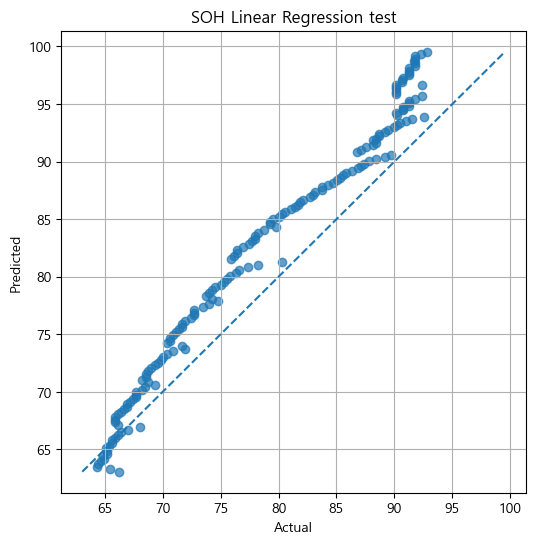

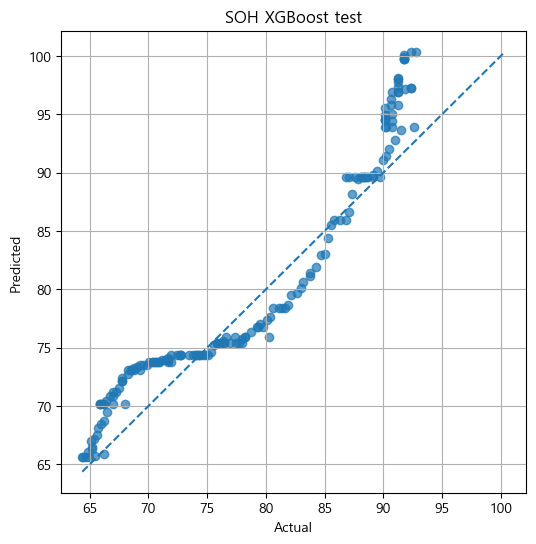

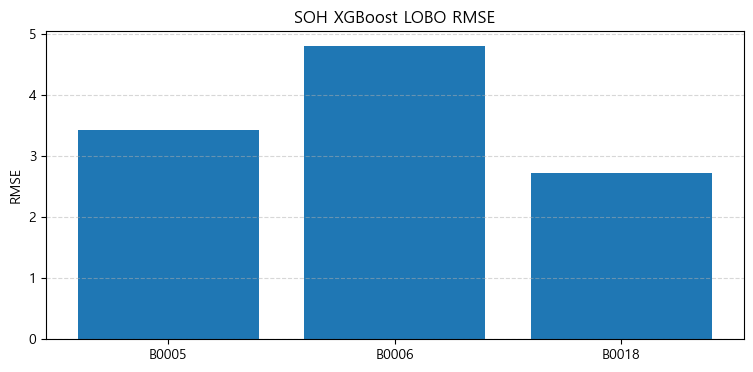

In [24]:
if SOH_RUNS['baseline_lr']['status'] == 'ok':
    print('SOH 선형회귀 계수표')
    print(SOH_RUNS['baseline_lr']['coef_df'].to_string(index=False))
    print()

if SOH_RUNS['baseline_xgb']['status'] == 'ok':
    print('SOH XGBoost 중요도')
    print(SOH_RUNS['baseline_xgb']['importance_df'].to_string(index=False))
    print()

plot_actual_vs_pred(SOH_RUNS['baseline_lr'], 'SOH Linear Regression test')
plot_actual_vs_pred(SOH_RUNS['baseline_xgb'], 'SOH XGBoost test')

plot_bar_table(
    df=SOH_RUNS['baseline_xgb']['lobo_detail_df'],
    x_col='held_out_battery',
    y_col='RMSE',
    title_text='SOH XGBoost LOBO RMSE',
    ylabel_text='RMSE'
)

## 16-4. RUL baseline 테이블 정리

RUL baseline은 전처리 최종본 기준(df_ml)으로 아래 4개 사용.

- `discharge_cycle_raw`
- `SOH_nominal`
- `Rct_mean`
- `impedance_available`

In [25]:
RUL_TARGET_COL = 'RUL'
RUL_CYCLE_COL = 'discharge_cycle_raw'

rul_baseline_feature_cols = ['discharge_cycle_raw', 'SOH_nominal', 'Rct_mean', 'impedance_available']
rul_raw_added_feature_cols = ['discharge_cycle_raw', 'SOH_nominal', 'Rct_mean', 'impedance_available', 'discharge_duration_sec']

rul_model_df = ml_base_df[
    ['battery_id', 'start_time', 'filename', 'discharge_cycle_raw', 'SOH_nominal', 'RUL', 'Rct_mean', 'impedance_available']
].copy()

rul_model_df = rul_model_df.sort_values(['battery_id', 'start_time']).reset_index(drop=True)

print('rul_model_df 행 수 :', len(rul_model_df))
print('rul_model_df battery 수 :', rul_model_df['battery_id'].nunique())
print()
print('RUL baseline feature :', rul_baseline_feature_cols)
rul_model_df.head()

rul_model_df 행 수 : 468
rul_model_df battery 수 : 3

RUL baseline feature : ['discharge_cycle_raw', 'SOH_nominal', 'Rct_mean', 'impedance_available']


,battery_id,start_time,filename,discharge_cycle_raw,SOH_nominal,RUL,Rct_mean,impedance_available
0,B0005,2008-04-02 15:25:41,05122.csv,1,92.82,124.0,NaN,0
1,B0005,2008-04-02 19:43:48,05124.csv,2,92.32,123.0,NaN,0
2,B0005,2008-04-03 00:01:06,05126.csv,3,91.77,122.0,NaN,0
3,B0005,2008-04-03 04:16:37,05128.csv,4,91.76,121.0,NaN,0
4,B0005,2008-04-03 08:33:25,05130.csv,5,91.73,120.0,NaN,0


## 16-5. raw csv에서 `discharge_duration_sec` 추출

rul_model_df의 filename 기준으로만 붙인다.

- raw csv가 있으면 Time의 최대값 - 최소값으로 방전 지속 시간을 계산
- raw csv가 없으면 결측으로 둔다(오류 방지)

In [26]:
raw_path_candidates = []

if 'base_path' in globals():
    raw_path_candidates.append(base_path)

raw_path_candidates.extend([
    '.',
    '/mnt/data',
    '/mnt/data/data'
])

# 중복 제거
raw_path_candidates = list(dict.fromkeys(raw_path_candidates))


def find_raw_file(filename):
    for folder in raw_path_candidates:
        file_path = os.path.join(folder, str(filename))
        if os.path.exists(file_path):
            return file_path
    return None


raw_duration_rows = []
missing_raw_files = []

raw_key_df = rul_model_df[['battery_id', 'start_time', 'discharge_cycle_raw', 'filename']].copy()
raw_key_df = raw_key_df[raw_key_df['start_time'].notna()].copy()
raw_key_df = raw_key_df[raw_key_df['filename'].notna()].copy()
raw_key_df = raw_key_df.drop_duplicates().copy()

for _, row in raw_key_df.iterrows():
    one_file_path = find_raw_file(row['filename'])

    if one_file_path is None:
        missing_raw_files.append(row['filename'])
        continue

    raw_csv = pd.read_csv(one_file_path)

    if 'Time' not in raw_csv.columns:
        duration_sec = np.nan
    else:
        time_s = pd.to_numeric(raw_csv['Time'], errors='coerce').dropna()

        if len(time_s) == 0:
            duration_sec = np.nan
        else:
            duration_sec = time_s.max() - time_s.min()

    raw_duration_rows.append([
        row['battery_id'],
        row['start_time'],
        row['discharge_cycle_raw'],
        row['filename'],
        duration_sec
    ])

raw_duration_df = pd.DataFrame(
    raw_duration_rows,
    columns=['battery_id', 'start_time', 'discharge_cycle_raw', 'filename', 'discharge_duration_sec']
)

print('raw_duration_df 행 수 :', len(raw_duration_df))
print('못 찾은 raw 파일 수 :', len(set(missing_raw_files)))

if len(missing_raw_files) > 0:
    print('예시 missing 파일 :', sorted(list(set(missing_raw_files)))[:10])

raw_duration_df.head()

raw_duration_df 행 수 : 468
못 찾은 raw 파일 수 : 0


,battery_id,start_time,discharge_cycle_raw,filename,discharge_duration_sec
0,B0005,2008-04-02 15:25:41,1,05122.csv,3690.234
1,B0005,2008-04-02 19:43:48,2,05124.csv,3672.344
2,B0005,2008-04-03 00:01:06,3,05126.csv,3651.641
3,B0005,2008-04-03 04:16:37,4,05128.csv,3631.563
4,B0005,2008-04-03 08:33:25,5,05130.csv,3629.172


In [27]:
rul_model_raw_df = rul_model_df.merge(
    raw_duration_df[['battery_id', 'start_time', 'discharge_cycle_raw', 'discharge_duration_sec']],
    on=['battery_id', 'start_time', 'discharge_cycle_raw'],
    how='left'
)

# 공정한 비교를 위해 raw feature가 실제로 붙은 행만 비교용으로 따로 만든다.
rul_same_rows_df = rul_model_raw_df[rul_model_raw_df['discharge_duration_sec'].notna()].copy()
rul_same_rows_df = rul_same_rows_df.sort_values(['battery_id', 'start_time']).reset_index(drop=True)

print('rul_model_raw_df 전체 행 수 :', len(rul_model_raw_df))
print('rul_same_rows_df 비교 행 수 :', len(rul_same_rows_df))
print('rul_same_rows_df battery 수 :', rul_same_rows_df['battery_id'].nunique())
print()
print('RUL raw-added feature :', rul_raw_added_feature_cols)
rul_same_rows_df.head()

rul_model_raw_df 전체 행 수 : 468
rul_same_rows_df 비교 행 수 : 468
rul_same_rows_df battery 수 : 3

RUL raw-added feature : ['discharge_cycle_raw', 'SOH_nominal', 'Rct_mean', 'impedance_available', 'discharge_duration_sec']


,battery_id,start_time,filename,discharge_cycle_raw,SOH_nominal,RUL,Rct_mean,impedance_available,discharge_duration_sec
0,B0005,2008-04-02 15:25:41,05122.csv,1,92.82,124.0,NaN,0,3690.234
1,B0005,2008-04-02 19:43:48,05124.csv,2,92.32,123.0,NaN,0,3672.344
2,B0005,2008-04-03 00:01:06,05126.csv,3,91.77,122.0,NaN,0,3651.641
3,B0005,2008-04-03 04:16:37,05128.csv,4,91.76,121.0,NaN,0,3631.563
4,B0005,2008-04-03 08:33:25,05130.csv,5,91.73,120.0,NaN,0,3629.172


## 16-6. 변수 지도

변수 지도를 보고 지금 어떤 변수에서 무엇을 확인해야 하는지 바로 찾을 수 있게 정리.

selected_rul_run이 현재 실제로 보고 있는 모델 결과 묶음이다.

In [28]:
ml_object_guide_rows = [
    ['ml_base_df', 'ML 공통 베이스 테이블', '전처리 최종본(df_ml)을 바탕으로 만든 머신러닝 기준 테이블', '전체 ML 흐름의 시작점과 공통 입력 데이터를 확인할 때'],
    ['soh_model_df', 'SOH baseline 학습 테이블', 'SOH baseline 학습에 실제로 사용한 최종 행과 feature 테이블', 'SOH 모델에 들어간 입력 행과 feature 구성을 확인할 때'],
    ["SOH_RUNS['baseline_lr']", 'SOH 선형회귀 결과 묶음', 'SOH 선형회귀의 성능, 계수, 예측 결과가 들어 있는 실행 결과 묶음', 'SOH 선형회귀 성능과 계수, 예측 결과를 확인할 때'],
    ["SOH_RUNS['baseline_xgb']", 'SOH XGBoost 결과 묶음', 'SOH XGBoost의 성능, 중요도, SHAP, 예측 결과가 들어 있는 실행 결과 묶음', 'SOH XGBoost 중요도, SHAP, 예측 결과를 확인할 때'],

    ['rul_model_df', 'RUL baseline 학습 테이블', 'RUL baseline 학습에 사용한 최종 feature 테이블', 'RUL baseline에 실제로 어떤 값이 들어갔는지 확인할 때'],
    ['raw_duration_df', 'raw feature 추출 테이블', 'raw csv에서 뽑은 discharge_duration_sec 값 테이블', 'raw feature가 제대로 생성되었는지 확인할 때'],
    ['rul_model_raw_df', 'RUL + raw feature 결합 테이블', 'RUL 전체 테이블에 raw feature를 붙인 확장 테이블', 'raw feature가 전체 행에 어떻게 붙었는지 확인할 때'],
    ['rul_same_rows_df', '공정 비교용 동일 행 테이블', 'raw feature가 실제로 존재하는 행만 남긴 비교용 테이블', 'baseline과 raw-added를 같은 행 기준으로 공정 비교할 때'],

    ["RUL_RUNS['baseline_lr']", 'RUL baseline 선형회귀 결과 묶음', 'RUL baseline 선형회귀의 성능, 계수, 예측 결과가 들어 있는 실행 결과 묶음', 'baseline 선형회귀 성능과 계수를 확인할 때'],
    ["RUL_RUNS['baseline_xgb']", 'RUL baseline XGBoost 결과 묶음', 'RUL baseline XGBoost의 성능, 중요도, SHAP, LOBO 결과가 들어 있는 실행 결과 묶음', 'baseline XGBoost 중요도, SHAP, LOBO 결과를 확인할 때'],
    ["RUL_RUNS['raw_added_lr']", 'RUL raw-added 선형회귀 결과 묶음', 'raw feature 추가 후 선형회귀의 성능, 계수, 예측 결과가 들어 있는 실행 결과 묶음', 'raw 추가 후 선형회귀 성능 변화를 확인할 때'],
    ["RUL_RUNS['raw_added_xgb']", 'RUL raw-added XGBoost 결과 묶음', 'raw feature 추가 후 XGBoost의 성능, 중요도, SHAP, 예측, LOBO가 들어 있는 실행 결과 묶음', '중요도 차트, SHAP, 예측 결과, LOBO를 한 번에 확인할 때'],

    ["RUL_RUNS['raw_added_xgb']['importance_df']", 'raw-added XGBoost 중요도 표', 'feature importance 값이 정리된 표', '중요도 bar chart를 만들 때'],
    ["RUL_RUNS['raw_added_xgb']['shap_mean_df']", 'raw-added XGBoost 평균 절대 SHAP 표', '평균 절대 SHAP 값이 정리된 표', 'SHAP bar chart를 만들 때'],
    ["RUL_RUNS['raw_added_xgb']['pred_df']", 'raw-added XGBoost 예측 결과 표', '실제값, 예측값, 오차가 정리된 예측 결과 표', '예측 결과 시각화나 오차 확인을 할 때'],
    ["RUL_RUNS['raw_added_xgb']['lobo_detail_df']", 'raw-added XGBoost 배터리별 LOBO 결과 표', '배터리별 LOBO 성능이 정리된 상세 결과 표', '배터리별 RMSE 비교를 할 때']
]

ml_object_guide_df = pd.DataFrame(
    ml_object_guide_rows,
    columns=['변수명', '역할', '포함 내용', '확인할 때']
)

ml_object_guide_df

,변수명,역할,포함 내용,확인할 때
0,ml_base_df,ML 공통 베이스 테이블,전처리 최종본(df_ml)을 바탕으로 만든 머신러닝 기준 테이블,전체 ML 흐름의 시작점과 공통 입력 데이터를 확인할 때
1,soh_model_df,SOH baseline 학습 테이블,SOH baseline 학습에 실제로 사용한 최종 행과 feature 테이블,SOH 모델에 들어간 입력 행과 feature 구성을 확인할 때
2,SOH_RUNS['baseline_lr'],SOH 선형회귀 결과 묶음,"SOH 선형회귀의 성능, 계수, 예측 결과가 들어 있는 실행 결과 묶음","SOH 선형회귀 성능과 계수, 예측 결과를 확인할 때"
3,SOH_RUNS['baseline_xgb'],SOH XGBoost 결과 묶음,"SOH XGBoost의 성능, 중요도, SHAP, 예측 결과가 들어 있는 실행 결과 묶음","SOH XGBoost 중요도, SHAP, 예측 결과를 확인할 때"
4,rul_model_df,RUL baseline 학습 테이블,RUL baseline 학습에 사용한 최종 feature 테이블,RUL baseline에 실제로 어떤 값이 들어갔는지 확인할 때
5,raw_duration_df,raw feature 추출 테이블,raw csv에서 뽑은 discharge_duration_sec 값 테이블,raw feature가 제대로 생성되었는지 확인할 때
6,rul_model_raw_df,RUL + raw feature 결합 테이블,RUL 전체 테이블에 raw feature를 붙인 확장 테이블,raw feature가 전체 행에 어떻게 붙었는지 확인할 때
7,rul_same_rows_df,공정 비교용 동일 행 테이블,raw feature가 실제로 존재하는 행만 남긴 비교용 테이블,baseline과 raw-added를 같은 행 기준으로 공정 비교할 때
8,RUL_RUNS['baseline_lr'],RUL baseline 선형회귀 결과 묶음,"RUL baseline 선형회귀의 성능, 계수, 예측 결과가 들어 있는 실행 결과 묶음",baseline 선형회귀 성능과 계수를 확인할 때
9,RUL_RUNS['baseline_xgb'],RUL baseline XGBoost 결과 묶음,"RUL baseline XGBoost의 성능, 중요도, SHAP, LOBO 결과가 ...","baseline XGBoost 중요도, SHAP, LOBO 결과를 확인할 때"


## 16-7. RUL 모델 학습

이름은 아래 4개로 고정.

- `baseline_lr`
- `baseline_xgb`
- `raw_added_lr`
- `raw_added_xgb`

지금 보고 있는 결과가  
baseline인지 / raw 추가 버전인지 / 선형인지 / XGBoost인지 알기 위함.

In [29]:
RUL_RUNS = {}

RUL_RUNS['baseline_lr'] = run_single_split_regression(
    model_df=rul_same_rows_df if len(rul_same_rows_df) > 0 else rul_model_df,
    feature_cols=rul_baseline_feature_cols,
    target_col=RUL_TARGET_COL,
    model_factory=LinearRegression
)
RUL_RUNS['baseline_lr'] = add_linear_coefficients(RUL_RUNS['baseline_lr'])
RUL_RUNS['baseline_lr']['lobo_detail_df'], RUL_RUNS['baseline_lr']['lobo_mean_df'] = run_lobo_regression(
    model_df=rul_same_rows_df if len(rul_same_rows_df) > 0 else rul_model_df,
    feature_cols=rul_baseline_feature_cols,
    target_col=RUL_TARGET_COL,
    model_factory=LinearRegression
)

RUL_RUNS['baseline_xgb'] = run_single_split_regression(
    model_df=rul_same_rows_df if len(rul_same_rows_df) > 0 else rul_model_df,
    feature_cols=rul_baseline_feature_cols,
    target_col=RUL_TARGET_COL,
    model_factory=make_xgb_regressor
)
RUL_RUNS['baseline_xgb'] = add_xgb_importance(RUL_RUNS['baseline_xgb'])
RUL_RUNS['baseline_xgb'] = add_shap_summary(RUL_RUNS['baseline_xgb'])
RUL_RUNS['baseline_xgb']['lobo_detail_df'], RUL_RUNS['baseline_xgb']['lobo_mean_df'] = run_lobo_regression(
    model_df=rul_same_rows_df if len(rul_same_rows_df) > 0 else rul_model_df,
    feature_cols=rul_baseline_feature_cols,
    target_col=RUL_TARGET_COL,
    model_factory=make_xgb_regressor
)

RUL_RUNS['raw_added_lr'] = run_single_split_regression(
    model_df=rul_same_rows_df,
    feature_cols=rul_raw_added_feature_cols,
    target_col=RUL_TARGET_COL,
    model_factory=LinearRegression
)
RUL_RUNS['raw_added_lr'] = add_linear_coefficients(RUL_RUNS['raw_added_lr'])
RUL_RUNS['raw_added_lr']['lobo_detail_df'], RUL_RUNS['raw_added_lr']['lobo_mean_df'] = run_lobo_regression(
    model_df=rul_same_rows_df,
    feature_cols=rul_raw_added_feature_cols,
    target_col=RUL_TARGET_COL,
    model_factory=LinearRegression
)

RUL_RUNS['raw_added_xgb'] = run_single_split_regression(
    model_df=rul_same_rows_df,
    feature_cols=rul_raw_added_feature_cols,
    target_col=RUL_TARGET_COL,
    model_factory=make_xgb_regressor
)
RUL_RUNS['raw_added_xgb'] = add_xgb_importance(RUL_RUNS['raw_added_xgb'])
RUL_RUNS['raw_added_xgb'] = add_shap_summary(RUL_RUNS['raw_added_xgb'])
RUL_RUNS['raw_added_xgb']['lobo_detail_df'], RUL_RUNS['raw_added_xgb']['lobo_mean_df'] = run_lobo_regression(
    model_df=rul_same_rows_df,
    feature_cols=rul_raw_added_feature_cols,
    target_col=RUL_TARGET_COL,
    model_factory=make_xgb_regressor
)

print('RUL_RUNS keys :', list(RUL_RUNS.keys()))
print()
for one_key, one_run in RUL_RUNS.items():
    print(one_key, '->', one_run['status'], ('/' + one_run['reason']) if one_run['reason'] else '')

RUL_RUNS keys : ['baseline_lr', 'baseline_xgb', 'raw_added_lr', 'raw_added_xgb']

baseline_lr -> ok 
baseline_xgb -> ok 
raw_added_lr -> ok 
raw_added_xgb -> ok 


In [30]:
ordered_run_keys = ['baseline_lr', 'baseline_xgb', 'raw_added_lr', 'raw_added_xgb']

model_name_map = {
    'baseline_lr': 'LinearRegression',
    'baseline_xgb': 'XGBoost',
    'raw_added_lr': 'LinearRegression',
    'raw_added_xgb': 'XGBoost'
}

feature_name_map = {
    'baseline_lr': 'baseline',
    'baseline_xgb': 'baseline',
    'raw_added_lr': 'raw_added',
    'raw_added_xgb': 'raw_added'
}

rul_compare_test_df = make_compare_metric_df(
    run_dict=RUL_RUNS,
    ordered_keys=ordered_run_keys,
    model_name_map=model_name_map,
    feature_name_map=feature_name_map
)

rul_compare_lobo_df = make_compare_lobo_df(
    run_dict=RUL_RUNS,
    ordered_keys=ordered_run_keys,
    model_name_map=model_name_map,
    feature_name_map=feature_name_map
)

baseline_lobo_detail_df = RUL_RUNS['baseline_xgb']['lobo_detail_df']
raw_added_lobo_detail_df = RUL_RUNS['raw_added_xgb']['lobo_detail_df']

if baseline_lobo_detail_df is not None and raw_added_lobo_detail_df is not None:
    baseline_lobo_df = baseline_lobo_detail_df[['held_out_battery', 'RMSE']].copy()
    baseline_lobo_df = baseline_lobo_df.rename(columns={'RMSE': 'baseline_rmse'})

    raw_added_lobo_df = raw_added_lobo_detail_df[['held_out_battery', 'RMSE']].copy()
    raw_added_lobo_df = raw_added_lobo_df.rename(columns={'RMSE': 'raw_added_rmse'})

    rul_xgb_lobo_compare_df = baseline_lobo_df.merge(
        raw_added_lobo_df,
        on='held_out_battery',
        how='inner'
    )

    rul_xgb_lobo_compare_df['rmse_diff'] = (
        rul_xgb_lobo_compare_df['raw_added_rmse'] - rul_xgb_lobo_compare_df['baseline_rmse']
    ).round(4)

    rul_xgb_lobo_compare_df = rul_xgb_lobo_compare_df.sort_values('held_out_battery').reset_index(drop=True)

else:
    rul_xgb_lobo_compare_df = pd.DataFrame(
        columns=['held_out_battery', 'baseline_rmse', 'raw_added_rmse', 'rmse_diff']
    )

print('RUL test 성능 비교')
print(rul_compare_test_df.to_string(index=False))
print()

print('RUL LOBO 평균 비교')
print(rul_compare_lobo_df.to_string(index=False))
print()

print('RUL XGBoost 배터리별 LOBO RMSE 비교')
print(rul_xgb_lobo_compare_df.to_string(index=False))

RUL test 성능 비교
           model feature_set     MAE    RMSE     R2
LinearRegression    baseline 24.9033 26.6964 0.5810
         XGBoost    baseline 12.1583 13.6117 0.8911
LinearRegression   raw_added 22.5084 23.9054 0.6640
         XGBoost   raw_added 11.7061 12.6241 0.9063

RUL LOBO 평균 비교
           model feature_set     MAE    RMSE     R2
LinearRegression    baseline 16.9688 19.7448 0.7041
         XGBoost    baseline  8.5817 10.7560 0.9136
LinearRegression   raw_added 15.6618 17.9827 0.7590
         XGBoost   raw_added  7.9347  9.4724 0.9329

RUL XGBoost 배터리별 LOBO RMSE 비교
held_out_battery  baseline_rmse  raw_added_rmse  rmse_diff
           B0005        13.6117         12.6241    -0.9876
           B0006         9.7059          8.2018    -1.5041
           B0018         8.9505          7.5914    -1.3591


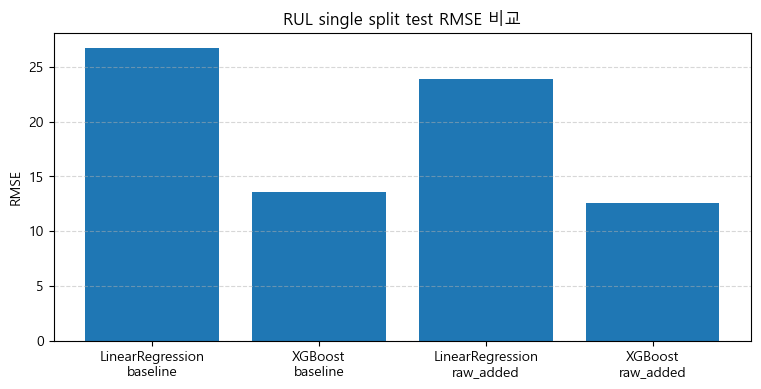

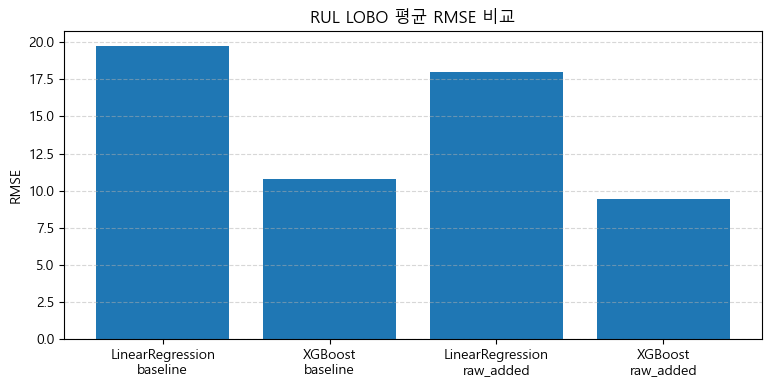

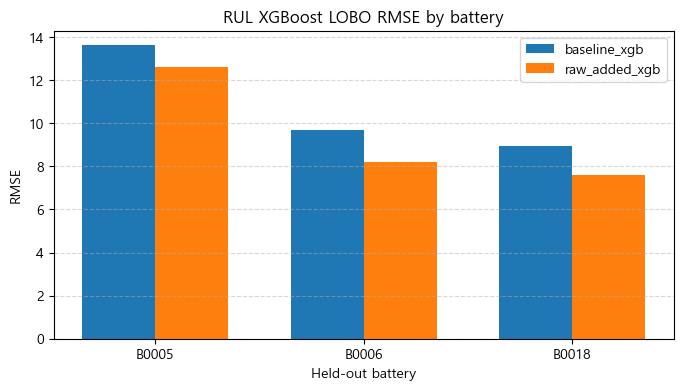

In [31]:
if len(rul_compare_test_df) > 0:
    rul_compare_test_plot_df = rul_compare_test_df.copy()
    rul_compare_test_plot_df['label'] = rul_compare_test_plot_df['model'] + '\n' + rul_compare_test_plot_df['feature_set']

    plot_bar_table(
        df=rul_compare_test_plot_df,
        x_col='label',
        y_col='RMSE',
        title_text='RUL single split test RMSE 비교',
        ylabel_text='RMSE'
    )

if len(rul_compare_lobo_df) > 0:
    rul_compare_lobo_plot_df = rul_compare_lobo_df.copy()
    rul_compare_lobo_plot_df['label'] = rul_compare_lobo_plot_df['model'] + '\n' + rul_compare_lobo_plot_df['feature_set']

    plot_bar_table(
        df=rul_compare_lobo_plot_df,
        x_col='label',
        y_col='RMSE',
        title_text='RUL LOBO 평균 RMSE 비교',
        ylabel_text='RMSE'
    )

if len(rul_xgb_lobo_compare_df) > 0:
    x = np.arange(len(rul_xgb_lobo_compare_df))
    width = 0.35

    plt.figure(figsize=(8, 4))
    plt.bar(x - width / 2, rul_xgb_lobo_compare_df['baseline_rmse'], width=width, label='baseline_xgb')
    plt.bar(x + width / 2, rul_xgb_lobo_compare_df['raw_added_rmse'], width=width, label='raw_added_xgb')
    plt.xticks(x, rul_xgb_lobo_compare_df['held_out_battery'])
    plt.xlabel('Held-out battery')
    plt.ylabel('RMSE')
    plt.title('RUL XGBoost LOBO RMSE by battery')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()
else:
    print('raw-added LOBO 비교 그래프는 현재 생략합니다.')

## 16-8. 중요도 / SHAP / 예측 결과 확인 기준

기본적으로 raw_added_xgb를 보고, 안 되면 baseline_xgb를 본다

In [32]:
if RUL_RUNS['raw_added_xgb']['status'] == 'ok':
    selected_rul_run_key = 'raw_added_xgb'
else:
    selected_rul_run_key = 'baseline_xgb'

selected_rul_run = RUL_RUNS[selected_rul_run_key]

print('현재 선택한 모델 :', selected_rul_run_key)
print('현재 feature 목록 :', selected_rul_run['feature_cols'])
print()
print("이 모델의 중요도 표 변수명 : RUL_RUNS[%r]['importance_df']" % selected_rul_run_key)
print("이 모델의 SHAP 표 변수명   : RUL_RUNS[%r]['shap_mean_df']" % selected_rul_run_key)
print("이 모델의 예측 결과 변수명 : RUL_RUNS[%r]['pred_df']" % selected_rul_run_key)
print("이 모델의 LOBO 결과 변수명 : RUL_RUNS[%r]['lobo_detail_df']" % selected_rul_run_key)

현재 선택한 모델 : raw_added_xgb
현재 feature 목록 : ['discharge_cycle_raw', 'SOH_nominal', 'Rct_mean', 'impedance_available', 'discharge_duration_sec']

이 모델의 중요도 표 변수명 : RUL_RUNS['raw_added_xgb']['importance_df']
이 모델의 SHAP 표 변수명   : RUL_RUNS['raw_added_xgb']['shap_mean_df']
이 모델의 예측 결과 변수명 : RUL_RUNS['raw_added_xgb']['pred_df']
이 모델의 LOBO 결과 변수명 : RUL_RUNS['raw_added_xgb']['lobo_detail_df']


선택 모델 test 성능표
  set     MAE    RMSE     R2
train  0.6982  1.1240 0.9989
 test 11.7061 12.6241 0.9063

선택 모델 중요도 표
               feature  importance
discharge_duration_sec    0.628311
           SOH_nominal    0.252439
   discharge_cycle_raw    0.096355
   impedance_available    0.013122
              Rct_mean    0.009774



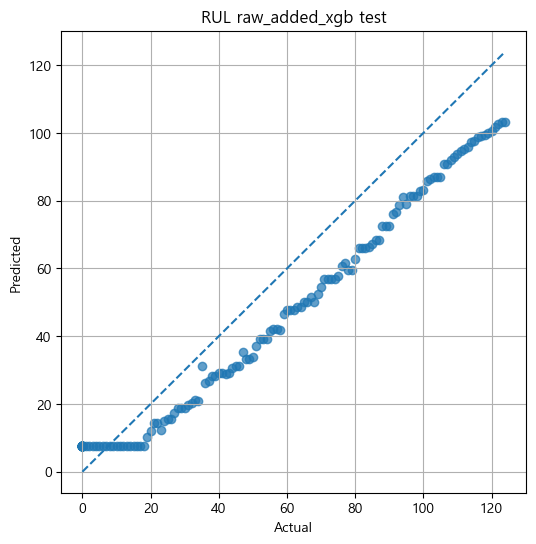

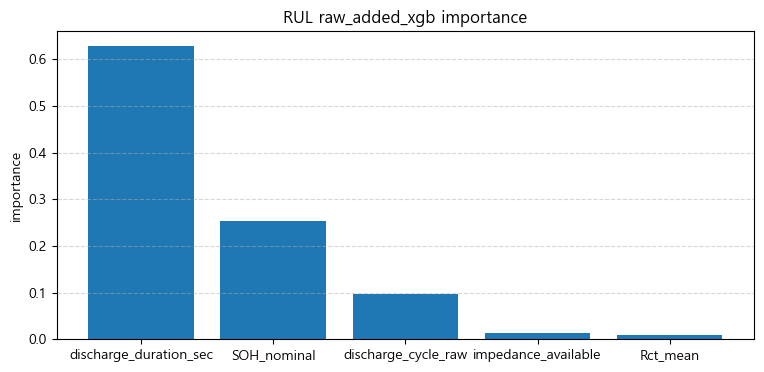

In [33]:
if selected_rul_run['status'] != 'ok':
    print('선택 모델이 학습되지 않았습니다.')
    print('사유 :', selected_rul_run['reason'])
else:
    print('선택 모델 test 성능표')
    print(selected_rul_run['metric_df'].to_string(index=False))
    print()

    print('선택 모델 중요도 표')
    print(selected_rul_run['importance_df'].to_string(index=False))
    print()

    plot_actual_vs_pred(selected_rul_run, f'RUL {selected_rul_run_key} test')

    plot_bar_table(
        df=selected_rul_run['importance_df'],
        x_col='feature',
        y_col='importance',
        title_text=f'RUL {selected_rul_run_key} importance',
        ylabel_text='importance'
    )

In [34]:
if selected_rul_run['status'] != 'ok':
    print('SHAP 출력도 생략합니다.')
elif selected_rul_run['shap_mean_df'] is None:
    print('SHAP를 계산하지 못했습니다.')
    print('오류 내용 :', selected_rul_run.get('shap_error'))
else:
    print('선택 모델 평균 절대 SHAP 표')
    print(selected_rul_run['shap_mean_df'].to_string(index=False))
    print()

    plot_bar_table(
        df=selected_rul_run['shap_mean_df'],
        x_col='feature',
        y_col='mean_abs_shap',
        title_text=f'RUL {selected_rul_run_key} SHAP mean(|value|)',
        ylabel_text='mean abs shap'
    )

    shap.summary_plot(
        selected_rul_run['shap_values'],
        selected_rul_run['X_test'],
        show=False
    )
    plt.show()

SHAP를 계산하지 못했습니다.
오류 내용 : SHAP import 실패


In [35]:
from IPython.display import display

In [36]:
#모델이 test 구간에서 RUL을 어떻게 예측했는지 행 단위로 확인
if selected_rul_run['status'] != 'ok':
    print('예측 결과 표도 생략합니다.')
else:
    selected_rul_pred_df = selected_rul_run['pred_df'].copy()
    selected_rul_test_pred_df = selected_rul_pred_df[selected_rul_pred_df['set'] == 'test'].copy()

    print('선택 모델 test 예측 결과 일부')
    display(
        selected_rul_test_pred_df[
            ['battery_id', 'start_time', 'y_true', 'y_pred', 'abs_error']
        ].head(20)
    )

선택 모델 test 예측 결과 일부


,battery_id,start_time,y_true,y_pred,abs_error
300,B0005,2008-04-02 15:25:41,124.0,103.131447,20.868553
301,B0005,2008-04-02 19:43:48,123.0,103.131447,19.868553
302,B0005,2008-04-03 00:01:06,122.0,102.523689,19.476311
303,B0005,2008-04-03 04:16:37,121.0,101.742393,19.257607
304,B0005,2008-04-03 08:33:25,120.0,100.494270,19.505730
305,B0005,2008-04-03 12:55:10,119.0,99.871681,19.128319
306,B0005,2008-04-03 17:17:16,118.0,99.472595,18.527405
307,B0005,2008-04-03 21:28:14,117.0,99.168053,17.831947
308,B0005,2008-04-04 01:38:15,116.0,98.680000,17.320000
309,B0005,2008-04-04 05:48:08,115.0,97.639809,17.360191


In [37]:
# 필요하면 머신러닝용 중간 결과도 저장
ml_save_candidates = [save_dir if 'save_dir' in globals() else base_path, '.', '/mnt/data']
ml_save_dir = None

for one_dir in ml_save_candidates:
    try:
        os.makedirs(one_dir, exist_ok=True)
        test_file = os.path.join(one_dir, '__ml_write_test__.tmp')
        with open(test_file, 'w', encoding='utf-8') as f:
            f.write('ok')
        os.remove(test_file)
        ml_save_dir = one_dir
        break
    except Exception:
        continue

if ml_save_dir is None:
    raise PermissionError('머신러닝 결과를 저장할 폴더를 찾지 못했습니다.')

ml_base_df.to_csv(os.path.join(ml_save_dir, 'df_ml_with_filename.csv'), index=False)
soh_model_df.to_csv(os.path.join(ml_save_dir, 'soh_model_df.csv'), index=False)
rul_model_df.to_csv(os.path.join(ml_save_dir, 'rul_model_df.csv'), index=False)
rul_model_raw_df.to_csv(os.path.join(ml_save_dir, 'rul_model_raw_df.csv'), index=False)

print('머신러닝 중간 테이블 저장 완료')
print(os.path.join(ml_save_dir, 'df_ml_with_filename.csv'))
print(os.path.join(ml_save_dir, 'soh_model_df.csv'))
print(os.path.join(ml_save_dir, 'rul_model_df.csv'))
print(os.path.join(ml_save_dir, 'rul_model_raw_df.csv'))

머신러닝 중간 테이블 저장 완료
data\df_ml_with_filename.csv
data\soh_model_df.csv
data\rul_model_df.csv
data\rul_model_raw_df.csv
